# One-Factor Spiked Covariance Experiment

This notebook studies the model

$$
A = f l^\top + E,\qquad A\in\mathbb{R}^{T \times N},
$$

where $f\in\mathbb{R}^T$ is a latent factor, $l\in\mathbb{R}^N$ is the fixed true loading direction, and $E$ is idiosyncratic noise.

The goal is to numerically verify the **BBP phase transition** for PCA in a rank-one spiked covariance model:

1. **Eigenvalue escape:** when does the largest sample covariance eigenvalue escape the pure-noise MP bulk?
2. **Eigenvector recovery:** when does the top PCA loading vector align with the true loading direction $l$?


## Assumptions and PCA Object

We assume the one-factor model

$$
A = f l^T + E
$$

where

$$
||l|| = 1
$$

$$
f_t \sim N(0, \tau^2)
$$

$$
E_{t,j} \sim N(0, \sigma^2)
$$

and the factor vector f is independent of the noise matrix E.

PCA studies the sample covariance matrix

$$
C = \frac{1}{T} A^T A.
$$

For pure noise, where A = E, the Marchenko-Pastur upper edge is

$$
\lambda_+ = \sigma^2(1+\sqrt q)^2
$$

with

$$
q = \frac{N}{T}.
$$

The population covariance of the one-factor model is

$$
\Sigma = E[a_t a_t^T] = \sigma^2 I_N + \tau^2 l l^T.
$$

After normalizing by the noise variance, define the population spike strength as

$$
\theta = \frac{\tau^2}{\sigma^2}.
$$

The BBP transition predicts that the sample spike separates from the MP bulk only when

$$
\theta > \sqrt q.
$$

Equivalently, the critical factor strength is

$$
\tau_c = \sigma q^{1/4}.
$$

Above this threshold, the top sample eigenvalue is predicted to approach

$$
\lambda_{out} = \sigma^2(1+\theta)\left(1+\frac{q}{\theta}\right).
$$


In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [23]:
def top_eigenpair(C):
    """Return eigenvalues/eigenvectors of symmetric C in descending order."""
    vals, vecs = np.linalg.eigh(C)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]


def alignment(u, v):
    """Absolute cosine similarity; sign does not matter for eigenvectors."""
    return abs(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))


def simulate_one_factor(T, N, tau, sigma=1.0, rng=None, l=None):
    """
    Simulate A = f l^T + E with A in R^{T x N}.

    tau is the standard deviation of the latent factor, so Var(f_t)=tau^2.
    sigma is the idiosyncratic noise standard deviation.
    l is the fixed true loading direction. If omitted, a new unit loading is sampled.
    """
    if rng is None:
        rng = np.random.default_rng()

    if l is None:
        l = rng.normal(size=N)
        l = l / np.linalg.norm(l)
    else:
        l = np.asarray(l)
        l = l / np.linalg.norm(l)

    f = rng.normal(0.0, tau, size=T)
    E = rng.normal(0.0, sigma, size=(T, N))
    A = f[:, None] @ l[None, :] + E

    C = A.T @ A / T
    vals, vecs = top_eigenpair(C)
    return vals[0], alignment(vecs[:, 0], l)


## Experiment Setup

We fix T, N, and sigma, then vary the factor strength tau. For each tau, we repeat the simulation several times and record:

- the largest eigenvalue of C;
- the alignment between the top PCA loading and the fixed true loading.

The true loading direction l is fixed for the whole experiment. Across trials, only the factor realization f and noise matrix E are resampled.

For our numerical choice,

$$
T = 600
$$

$$
N = 180
$$

$$
q = \frac{N}{T} = 0.3
$$

$$
\sigma = 1.
$$

Therefore the BBP critical values are

$$
\theta_c = \sqrt q \approx 0.548
$$

and

$$
\tau_c = \sigma q^{1/4} \approx 0.740.
$$

Our grid tau = 0, 0.2, ..., 4.0 contains values below the threshold, and the two grid points tau = 0.6 and tau = 0.8 bracket the critical point. Thus the experiment is designed to show the transition from the subcritical regime to the supercritical regime.

The experiment checks the BBP prediction:

- below tau_c, the leading eigenvalue should remain near the MP edge and PCA should have weak recovery;
- above tau_c, the leading eigenvalue should follow the outlier curve and the top eigenvector should align with l.


In [25]:
T = 600
N = 180
q = N / T
sigma = 1.0

mp_lower = sigma**2 * (1 - np.sqrt(q))**2
mp_upper = sigma**2 * (1 + np.sqrt(q))**2

theta_crit = np.sqrt(q)
tau_crit = sigma * q**0.25

taus = np.linspace(0.0, 4.0, 21)
thetas = (taus / sigma) ** 2

bbp_outlier = np.full_like(taus, np.nan, dtype=float)
mask = thetas > theta_crit
bbp_outlier[mask] = sigma**2 * (1 + thetas[mask]) * (1 + q / thetas[mask])

n_trials = 30

print(f"T={T}, N={N}, q=N/T={q:.3f}")
print(f"MP lower edge = {mp_lower:.3f}")
print(f"MP upper edge = {mp_upper:.3f}")
print(f"BBP critical theta = sqrt(q) = {theta_crit:.3f}")
print(f"BBP critical tau = sigma * q^(1/4) = {tau_crit:.3f}")
print(f"Tau grid brackets tau_c between {taus[taus < tau_crit][-1]:.1f} and {taus[taus > tau_crit][0]:.1f}")


T=600, N=180, q=N/T=0.300
MP lower edge = 0.205
MP upper edge = 2.395
BBP critical theta = sqrt(q) = 0.548
BBP critical tau = sigma * q^(1/4) = 0.740
Tau grid brackets tau_c between 0.6 and 0.8


In [26]:
rng = np.random.default_rng(42)

# Fix one true loading direction for the whole experiment.
# Across trials, only the factor f and noise E are resampled.
fixed_l = rng.normal(size=N)
fixed_l = fixed_l / np.linalg.norm(fixed_l)

lambda1_mean = []
lambda1_std = []
align_mean = []
align_std = []

for tau in taus:
    lambda_trials = []
    align_trials = []

    for _ in range(n_trials):
        lambda1, ali = simulate_one_factor(T, N, tau, sigma=sigma, rng=rng, l=fixed_l)
        lambda_trials.append(lambda1)
        align_trials.append(ali)

    lambda1_mean.append(np.mean(lambda_trials))
    lambda1_std.append(np.std(lambda_trials))
    align_mean.append(np.mean(align_trials))
    align_std.append(np.std(align_trials))

lambda1_mean = np.array(lambda1_mean)
lambda1_std = np.array(lambda1_std)
align_mean = np.array(align_mean)
align_std = np.array(align_std)


## Experiment 1: Spike Emergence

This plot shows how the largest eigenvalue changes as factor strength tau increases.

The red dashed horizontal line is the MP upper edge for pure noise. The purple dotted vertical line is the BBP threshold tau_c. The black dashed curve is the BBP outlier prediction:

$$
\lambda_{out} = \sigma^2(1+\theta)\left(1+\frac{q}{\theta}\right)
$$

where

$$
\theta = \frac{\tau^2}{\sigma^2}.
$$

The purpose is to see whether the simulated largest eigenvalue stays near the MP edge below the threshold and separates above it.


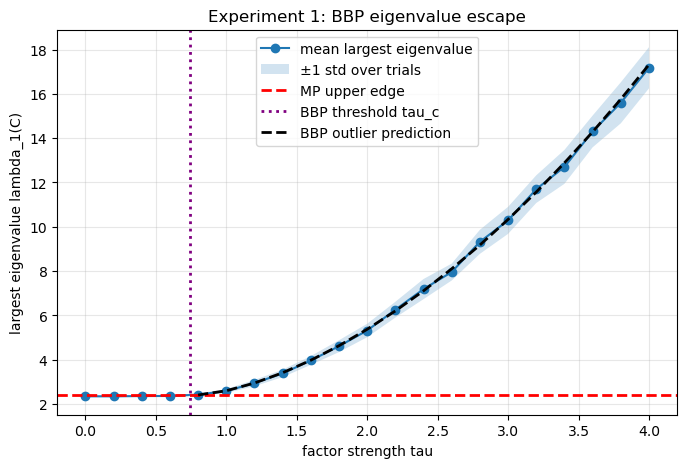

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(taus, lambda1_mean, marker="o", label="mean largest eigenvalue")
plt.fill_between(
    taus,
    lambda1_mean - lambda1_std,
    lambda1_mean + lambda1_std,
    alpha=0.2,
    label="±1 std over trials",
)
plt.axhline(mp_upper, color="red", linestyle="--", linewidth=2, label="MP upper edge")
plt.axvline(tau_crit, color="purple", linestyle=":", linewidth=2, label="BBP threshold tau_c")
plt.plot(taus, bbp_outlier, color="black", linestyle="--", linewidth=2, label="BBP outlier prediction")
plt.xlabel("factor strength tau")
plt.ylabel("largest eigenvalue lambda_1(C)")
plt.title("Experiment 1: BBP eigenvalue escape")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Experiment 2: PCA Recovery

This plot shows whether the top PCA loading vector recovers the true loading direction l.

We measure recovery using the absolute alignment:

$$
|<v_1,l>|.
$$

The absolute value is used because eigenvectors are only defined up to a sign. The BBP transition predicts weak alignment below tau_c and nontrivial alignment above the threshold.


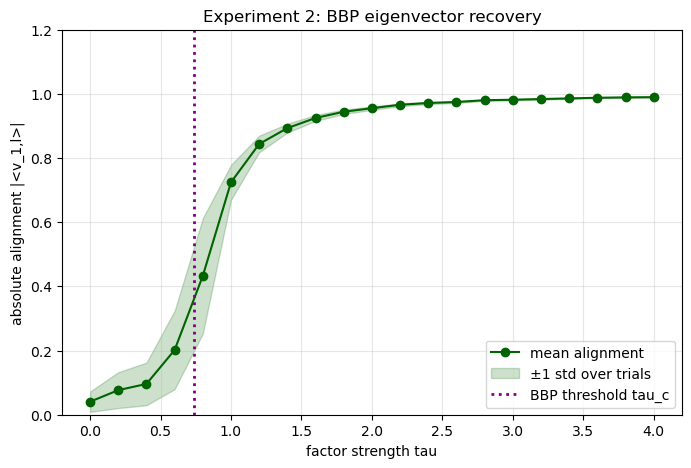

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(taus, align_mean, marker="o", color="darkgreen", label="mean alignment")
plt.fill_between(
    taus,
    align_mean - align_std,
    align_mean + align_std,
    alpha=0.2,
    color="darkgreen",
    label="±1 std over trials",
)
plt.axvline(tau_crit, color="purple", linestyle=":", linewidth=2, label="BBP threshold tau_c")
plt.xlabel("factor strength tau")
plt.ylabel("absolute alignment |<v_1,l>|")
plt.title("Experiment 2: BBP eigenvector recovery")
plt.ylim(0, 1.2)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Interpretation

The two experiments are a numerical check of the BBP phase transition.

Below the critical value tau_c, the population spike is too weak to reliably separate from high-dimensional sample noise. The largest eigenvalue remains near the MP edge, and the top PCA loading has weak alignment with l.

Above the critical value tau_c, the largest eigenvalue separates from the MP bulk and approaches the BBP outlier curve. At the same time, the top PCA loading becomes increasingly aligned with the true loading direction.

This supports the project thesis:

> PCA always returns principal components, but BBP theory predicts when a low-rank population signal becomes detectable in the sample covariance spectrum and recoverable through the leading eigenvector.
